In [2]:
import numpy as np  
import matplotlib.pyplot as plt 
import random
from random import sample
from scipy import stats
import emcee
import time
import math
import corner

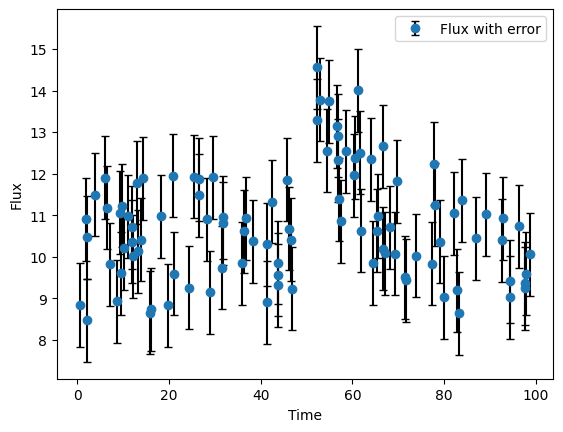

In [3]:
data=np.load("Transient.npy")
times=data[:,0]
flux=data[:,1]
err=data[:,2]
plt.errorbar(times, flux, yerr=err, fmt='o', ecolor='black', capsize=3, label='Flux with error')
plt.xlabel("Time")
plt.ylabel("Flux")
plt.legend()
plt.show()

Try with Log to avoid RuntimeWarning

In [10]:
def model(x):
    array=np.full_like(times,1)
    array[times<=x[0]]=x[1]
    array[times>x[0]]=x[1]+x[2]*np.exp(-x[3]*(times[times>x[0]]-x[0]))
    return array

def LogLikelihood(x):
   return  -np.sum(((flux-model(x))/err)**2+np.log(2*np.pi*err**2))

def prior_t0(x):
    if x[0]<0 or x[0]>100:
        return 0
    else:
        return 1/100

def prior_A(x):
    if x[2]<0 or x[2]>50:
        return 0
    else:
        return 1/50
    
def prior_b(x):
    if x[1]<0 or x[1]>50:
        return 0
    else:
        return 1/50

def prior_alpha(x):
    if x[3]<math.exp(-5) or x[3]>math.exp(5):
        return 0
    else:
        return 1/10/x[3]
    
def prior(x):
    return prior_t0(x)*prior_A(x)*prior_b(x)*prior_alpha(x)

def LogPosterior (x):
    if prior(x)==0:
        return -np.inf
    lp = np.log(prior(x))
    if not np.isfinite(lp): # if not True (np.isfinite returns True if it is finite )
        return -np.inf
    if not LogLikelihood(x):
        return -np.inf
    else:
        return LogLikelihood(x)+lp


In [42]:
ndim = 4  # number of parameters in the model
nwalkers = 10  # number of MCMC walkers
burn = 2000  # "burn-in" period to let chains stabilize
nsteps = 20000  # number of MCMC steps to take **for each walker**

# initialize theta 
np.random.seed(0)
starting_guesses = np.array([50,10,4,0.2])+1e-3*np.random.random((nwalkers, ndim)) #starting point for each walker for each parameter

# the function call where all the work happens: 
sampler = emcee.EnsembleSampler(nwalkers, ndim, LogPosterior)

elapsed=time.time()
sampler.run_mcmc(starting_guesses, nsteps)
print(time.time()-elapsed)

#throw-out the burn-in points and reshape:
emcee_trace  = sampler.chain[:, burn:, :].reshape(-1, ndim)

print(sampler.chain.shape) #original chain structure
print(emcee_trace.shape)

47.49606204032898
(10, 20000, 4)
(180000, 4)


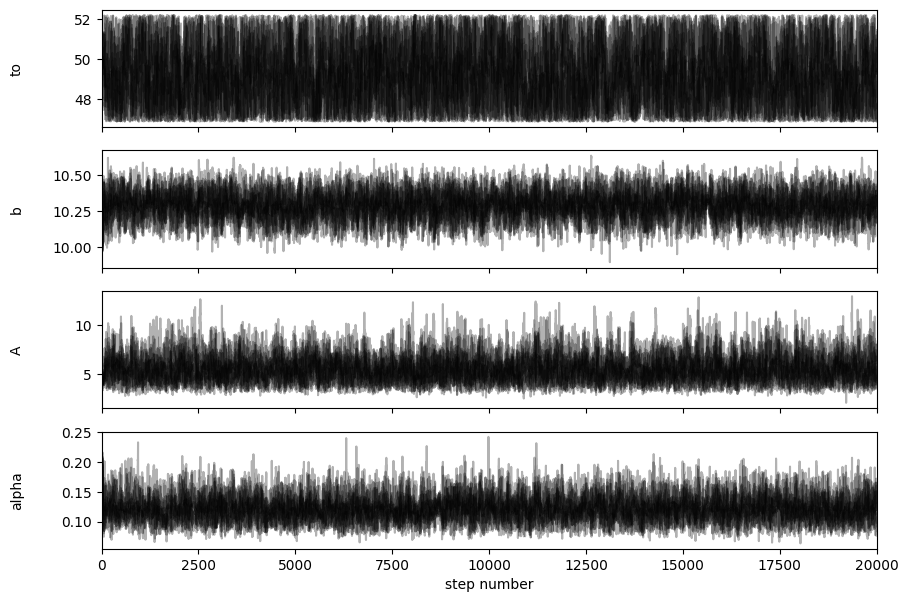

In [43]:
#plot showing the entire chain

fig, axes = plt.subplots(4, figsize=(10, 7), sharex=True)
samples = sampler.get_chain()
labels = ["to","b", "A", "alpha"]
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, :, i], "k", alpha=0.3)
    ax.set_xlim(0, len(samples))
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("step number");


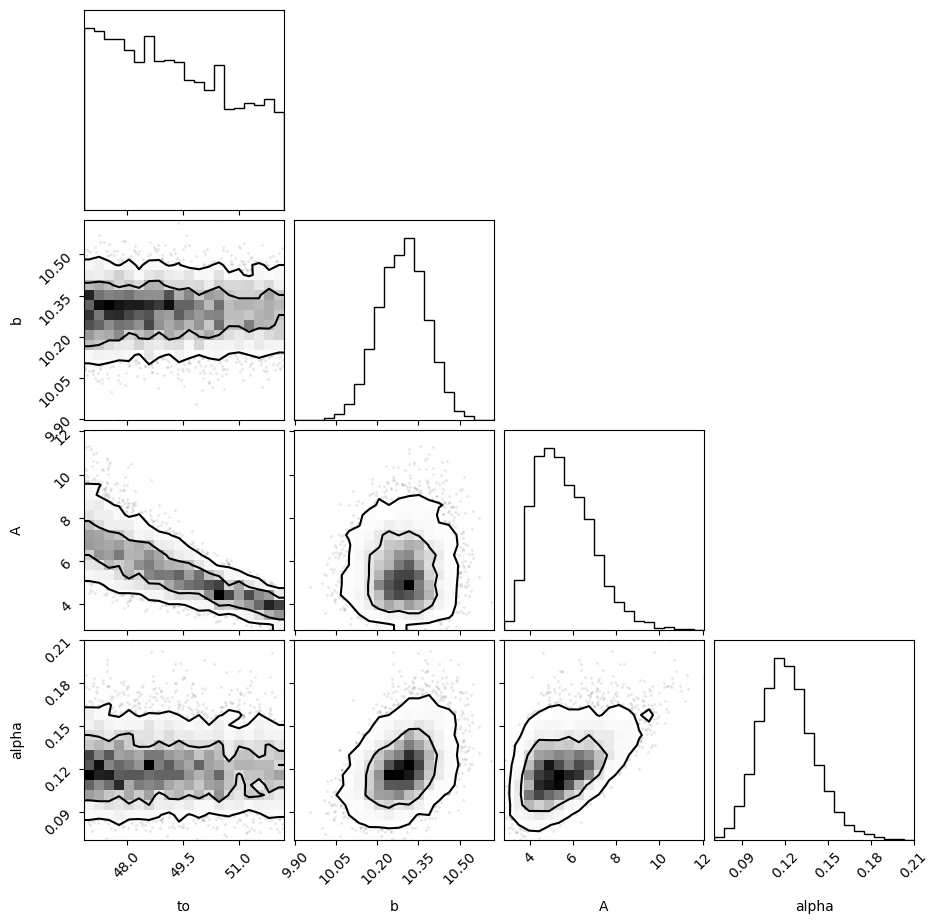

In [44]:
flat_samples = sampler.get_chain(discard=100, thin=30, flat=True)
fig = corner.corner(flat_samples, labels=labels, levels=[0.68,0.95])